# Load and Clean Data

In [1]:
import pandas as pd
#load data
df = pd.read_csv('employee_promotion_prediction.csv')
df.drop(columns='employee_id', inplace=True)
print(df.head())
print(df.info())

   age  gender education_level marital_status city_tier   department  \
0   50  Female          Master        Married     Tier1      Finance   
1   36    Male        Bachelor        Married     Tier1        Sales   
2   29  Female        Bachelor        Married     Tier2  Engineering   
3   42    Male        Bachelor        Married     Tier1   Operations   
4   40  Female          Master        Married     Tier1   Operations   

  employment_type  years_at_company  years_in_current_role  \
0       Full-time                10                      4   
1       Full-time                 9                      5   
2       Full-time                 7                      5   
3       Full-time                 4                      4   
4       Full-time                 2                      2   

   years_since_last_promotion  ...         salary  salary_increase_percent  \
0                          10  ...  137633.720337                 7.587737   
1                           3  ...  11

The dataset contains 100000 observations and 42 variables. There are both numerical and categorical variables. All variables had 100000 non-null values, meaning that there are no missing values in the dataset. The variable promoted is the target and is coded as 0 for not promoted and 1 for promoted.

# Exploratory Data Analysis

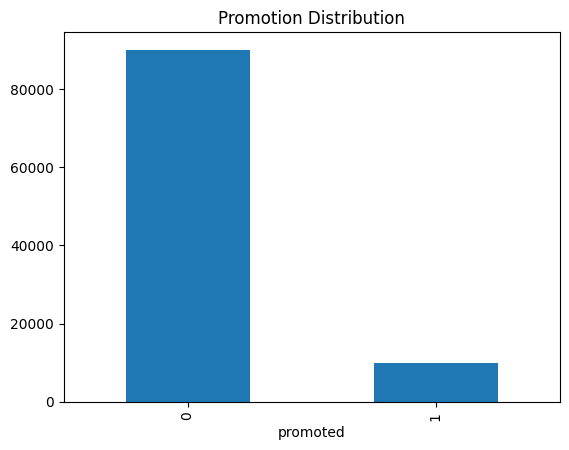

                 age  years_at_company  years_in_current_role  \
count  100000.000000     100000.000000          100000.000000   
mean       40.558140          5.489030               2.750630   
std        10.951788          3.481758               2.746004   
min        22.000000          0.000000               0.000000   
25%        31.000000          3.000000               1.000000   
50%        41.000000          5.000000               2.000000   
75%        50.000000          7.000000               4.000000   
max        59.000000         30.000000              28.000000   

       years_since_last_promotion      team_size  performance_score  \
count               100000.000000  100000.000000      100000.000000   
mean                     2.749650      11.014010          70.097429   
std                      2.733337       4.910633          14.717013   
min                      0.000000       3.000000          40.000000   
25%                      1.000000       7.000000          5

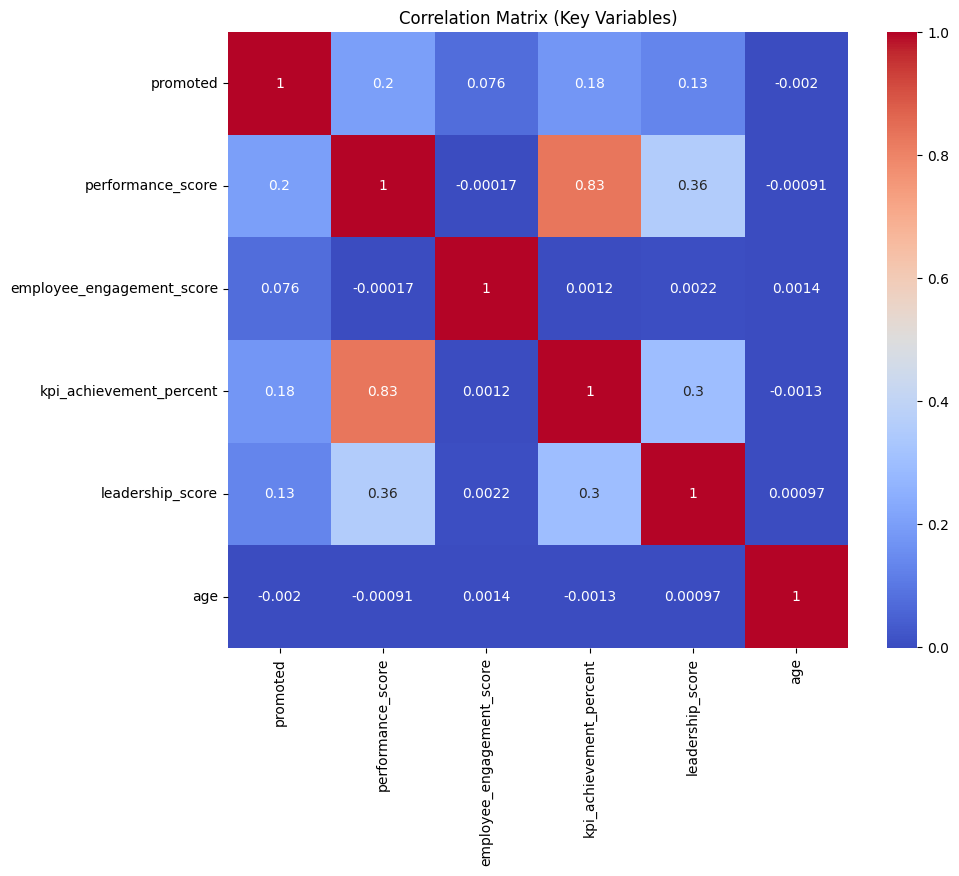

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
df['promoted'].value_counts().plot(kind='bar')
plt.title('Promotion Distribution')
plt.show()
#summary statistics
print(df.describe())
#correlation matrix
key_variables=['promoted','performance_score','employee_engagement_score','kpi_achievement_percent','leadership_score','age']
plt.figure(figsize=(10,8))
sns.heatmap(df[key_variables].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (Key Variables)')
plt.show()

The dataset is highly imbalanced, with roughly 10 percent of employees being promoted. Promotion is a rare occurrence and may impact the model's overall performance. The average employee is roughly 40.56 years old, with an average performance score of 70.10 and average engagement score of 69.92. Thes suggest a moderate performance and engagement level across the dataset. There is a good amount of variability, for instance, the performance score standard deviation is 14.72.

Promotion has a weak positive correlation with performance score (roughly 0.20) and KPI achievement (roughly 0.18), suggesting that higher-performing employees are slightly more likely to be promoted. Other variables, such as engagement and age, show weak relationships with promotion, suggesting that there is a weak association.

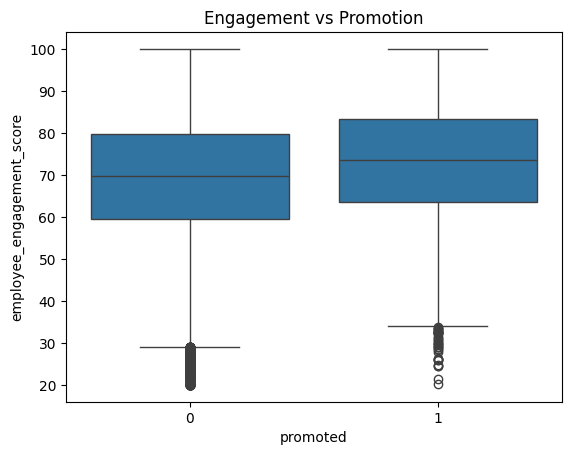

In [3]:
#engagement vs promotion
sns.boxplot(x='promoted', y='employee_engagement_score', data=df)
plt.title('Engagement vs Promotion')
plt.show()

The boxplot shows that promoted employees tend to have higher engagement scores than non-promoted employees. This visual difference suggests that there is a potential relationship, which is tested in the hypothesis testing section.

# Hypothesis Testing (Engagement vs Promotion)
- H_0: Mean engagement is the same for promoted and non-promoted employees
- H_1: Mean engagement differs between groups

In [4]:
import numpy as np 
from scipy import stats
#random sampling is used to avoid overpowering the t-test
eng_promoted = df[df['promoted']==1]['employee_engagement_score'].sample(n=50,random_state=25)
eng_not_promoted = df[df['promoted']==0]['employee_engagement_score'].sample(n=50,random_state=25)
t_stat,p_value = stats.ttest_ind(eng_promoted, eng_not_promoted)
print(f"T-statistic: {t_stat}, P-value: {p_value}")
alpha=0.05
if p_value<alpha:
    print("Reject null hypothesis: Significant difference in engagement scores between promoted and not promoted employees.")
else:
    print("Fail to reject null hypothesis: No significant difference in engagement scores between promoted and not promoted employees.")

T-statistic: 3.1421960214343616, P-value: 0.002218193499512642
Reject null hypothesis: Significant difference in engagement scores between promoted and not promoted employees.


The t-test produced a t-statistic of roughly 3.1422 and p-value of roughly 0.0022, which is below the significance level of 0.05. We reject the null hypothesis and can say there is a statistically significant difference in engagement scores between promoted and non-promoted employees. The small p-value means tahat the difference is not due to chance and that employee engagement is meaningfully associated with promotion. 

# Logistic Regression

In [5]:
import statsmodels.api as sm
import numpy as np
df_model = pd.get_dummies(df,drop_first=True,dtype=int)
X = df_model[['age', 'employee_engagement_score', 'performance_score', 'gender_Male','department_Finance','department_HR','department_Marketing','department_Operations','department_Sales','department_Support','education_level_Master','education_level_PhD']]
y = df_model['promoted']
X = sm.add_constant(X)
model=sm.Logit(y,X)
result = model.fit()
print(result.summary())
#odds ratios
odds = np.exp(result.params)
print(odds)

Optimization terminated successfully.
         Current function value: 0.252493
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               promoted   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99987
Method:                           MLE   Df Model:                           12
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.2233
Time:                        08:20:33   Log-Likelihood:                -25249.
converged:                       True   LL-Null:                       -32508.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -6.3721      0.102    -62.336      0.000      -6.

The model has a pseudo R^2 of 0.2233, meaning that roughly 22.33% of the variation in promotion outcomes is explained by the included variables. This model has a low to moderate level of explanatory power for a logistic regression model.

The coefficient for performance score is 0.0574 with a p value less than 0.001, with an odds ratio of 1.059. For each one-unit increase in performance score, the odds of promotion increase by roughly 5.9%. This is one of the strongest predictors in the model. 

The coefficient for engagement score is 0.0217 with a p value less than 0.001 and an odds ratio of 1.022. This means that there is a higher likelihood of promotion for employees with higher engagement. 

The coefficient for gender (male) is 0.0704 with a p value of roughly 0.003 and an odds ratio of 1.073. Male employees have a roughly 7.3% higher odds of promotion compared to female employees.

Age is not statistically significant, the p value is 0.650. Age does not have a meaningful effect on promotion when controlling for other variables.

Department has a strong effect on promotion. Engineering is the baseline category, all other departments are compared relative to engineering. Finace has an odds ratio of roughly .139, HR roughly 0.046, Sales roughly 0.203, and Support 0.030. These results suggest that department plays a major role in promotion. 

Both Masters and PhD degrees are statistically insignificant with p-values of .096 and .411, respectively. 

# Machine Learning (DecisionTreeClassifier)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

df_majority = df_model[df_model['promoted']==0]
df_minority = df_model[df_model['promoted']==1]
df_majority_sampled = df_majority.sample(n=len(df_minority), random_state=25)
df_balanced = pd.concat([df_majority_sampled, df_minority])
X = df_balanced[['age','employee_engagement_score','performance_score','gender_Male','department_Finance','department_HR','department_Marketing','department_Operations','department_Sales','department_Support','education_level_Master','education_level_PhD']]
y = df_balanced['promoted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)
tree=DecisionTreeClassifier(max_depth=5)
tree.fit(X_train,y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))
print("Testing Classification Report:")
print(classification_report(y_test, y_test_pred))

Training Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.57      0.66      7020
           1       0.66      0.84      0.74      6980

    accuracy                           0.70     14000
   macro avg       0.72      0.70      0.70     14000
weighted avg       0.72      0.70      0.70     14000

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.55      0.64      2980
           1       0.65      0.83      0.73      3020

    accuracy                           0.69      6000
   macro avg       0.71      0.69      0.68      6000
weighted avg       0.71      0.69      0.68      6000



The decision tree model had rough 70% accuracy on training dataset and 69% accuracy on testing dataset; there is no strong evidence of overfitting. After balancing the dataset, the model is able to identify both promoted and non-promoted employees. The recall for the promoted class is about 0.83 - 0.84, but the precision for the non-promoted class is lower, meaning there is some misclassification.

# Machine Learning (Naive Bayes)

In [7]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
X_nb = df_balanced[['age', 'employee_engagement_score','performance_score','gender_Male','department_Finance','department_HR','department_Marketing','department_Operations','department_Sales','department_Support','education_level_Master','education_level_PhD']]
y_nb = df_balanced['promoted']
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.3, random_state=25)
nb = GaussianNB()
nb.fit(X_train_nb, y_train_nb)
y_train_pred_nb = nb.predict(X_train_nb)
y_test_pred_nb = nb.predict(X_test_nb)
print("Training Classification Report:")
print(classification_report(y_train_nb, y_train_pred_nb))
print("Testing Classification Report:")
print(classification_report(y_test_nb, y_test_pred_nb))

Training Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.52      0.63      7020
           1       0.64      0.86      0.74      6980

    accuracy                           0.69     14000
   macro avg       0.72      0.69      0.68     14000
weighted avg       0.72      0.69      0.68     14000

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.50      0.61      2980
           1       0.64      0.86      0.73      3020

    accuracy                           0.68      6000
   macro avg       0.71      0.68      0.67      6000
weighted avg       0.71      0.68      0.67      6000



The Naive Bayes classifier produced consistent results between training and testing datasets, and the model does not show signs of overfitting. With the balanced dataset, the model can identify promoted and non-promoted employees. It has a recall of around 0.86 for the promoted class, but its overall accuracy is a bit lower than the decision tree. 

# Conclusion

This analysis used exploratory data analysis, hypothesis testing, and logistic regression to examine the variables influenicing employee promotion. Performance and factors such as department play the largest role in promotions. Engagement is significantly higher among promoted employees, suggesting that its important. Demographic variables such as age show more limited influence on promotion. Machine learning models were used to validate these findings. Class imbalance was addressed through subsampling, and both the decision tree and Naive Bayes models were able to identify promoted employees. The decision tree had moderate accuracy and balanced performance across classes, while the Naive Bayes model had somewhat better recall for the promoted class. The training and testing results were consistent across both models, showing no strong signs of overfitting.